# Ptychography tutorial 03 (constraints)

This notebook demonstrates the ptychography constraint API. Constraints are passed
to `reconstruct(...)` through a single `constraints=` dict keyed by `"object"`,
`"probe"`, and/or `"dataset"`. Each value may be either a typed dataclass instance
or a plain dict of field overrides:

```python
ptycho.reconstruct(
    constraints={
        "object": PtychoObjConstraintParams.Raster(tv_weight_xy=0.05),
        "probe": {"center_probe": True},  # partial dict-update of defaults
    },
)
```

Tab-complete on `PtychoObjConstraintParams.<TAB>` to see variants; tab-complete
inside `PtychoObjConstraintParams.Raster(<TAB>)` to see every field with its default.

We log every run to TensorBoard so the impact of each constraint is easy to compare
side-by-side.

Note that this notebook is not intended to demonstrate constraints improving reconstructions, just how to easily access and use constraints.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path

import numpy as np

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import OptimizerParams, SchedulerParams
from quantem.core.visualization import show_2d
from quantem.diffractive_imaging import (
    DetectorPixelated,
    ObjectPixelated,
    ProbePixelated,
    PtychoDatasetConstraintParams,
    PtychoObjConstraintParams,
    PtychoProbeConstraintParams,
    Ptychography,
    PtychographyDatasetRaster,
)
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

print(f"quantEM version: {em.__version__}")

GPU_ID = 0
config.set_device(GPU_ID)
print(f"Using GPU {config.get('device')}")

/home/amccray/code/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


quantEM version: 0.1.8
Using GPU cuda:2


## Discoverable defaults

Each constraint dataclass `__str__`s its full set of hard and soft fields with
their default values. In a notebook you can also tab-complete inside the constructor
to see field names and types inline.


In [3]:
print("Object constraints:")
print(PtychoObjConstraintParams.Raster())
print()
print("Probe constraints:")
print(PtychoProbeConstraintParams.Raster())
print()
print("Dataset constraints:")
print(PtychoDatasetConstraintParams.Raster())

Object constraints:
Constraints:
  Hard constraints:
    positivity: True
    positivity_mode: clamp
    fix_potential_baseline: False
    fix_potential_baseline_factor: 1.0
    identical_slices: False
    apply_fov_mask: False
    gaussian_sigma: None
    butterworth_order: 4
    q_lowpass: None
    q_highpass: None
  Soft constraints:
    tv_weight_z: 0.0
    tv_weight_xy: 0.0
    surface_zero_weight: 0.0

Probe constraints:
Constraints:
  Hard constraints:
    orthogonalize_probe: True
    center_probe: False
  Soft constraints:
    tv_weight: 0.0

Dataset constraints:
Constraints:
  Hard constraints:
    descan_shifts_zero: False
    center_scan_positions: False
    clip_scan_positions: True
  Soft constraints:
    descan_tv_weight: 0.0


## Load the `ducky` dataset

In [4]:
filepath = Path("../../data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
dset: Dataset4dstem = em.io.load(filepath)
print(dset)

PROBE_ENERGY = 80e3   # eV
PROBE_SEMIANGLE = 20  # mrad
PROBE_DEFOCUS = 500   # A

quantem Dataset named 'ducky_251105_clean'
  shape: (37, 37, 200, 200)
  dtype: float32
  device: cpu
  origin: [0. 0. 0. 0.]
  sampling: [4.    4.    0.025 0.025]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'


## Build a reusable Ptychography instance

We construct one `Ptychography` object and call `reconstruct(..., reset=True)`
for each constraint experiment. Each run logs to a distinct TensorBoard
`run_suffix` so the curves are easy to compare.


In [5]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=False,
    plot_com=False,
)

obj_model = ObjectPixelated.from_uniform(
    obj_type="pure_phase",
    num_slices=1,
)

probe_model = ProbePixelated.from_params(
    probe_params={
        "energy": PROBE_ENERGY,
        "defocus": PROBE_DEFOCUS,
        "semiangle_cutoff": PROBE_SEMIANGLE,
    },
)

detector_model = DetectorPixelated()

Calculated best fit rotation = 0 degrees.


Normalizing intensities: 100%|██████████| 1369/1369 [00:01<00:00, 850.78probe position/s]


In [6]:
LOG_DIR = Path("../../outputs/diffractive_imaging/logs/constraints_tutorial")
LOG_DIR.mkdir(parents=True, exist_ok=True)

def make_logger(suffix: str) -> LoggerPtychography:
    return LoggerPtychography(
        log_dir=LOG_DIR,
        run_prefix="ducky",
        run_suffix=suffix,
        log_images_every=10,
        log_probe_images=False,
    )

def show_zoom(ptycho, title=""):
    r1 = slice(10, 110), slice(10, 110)
    r2 = slice(220, 320), slice(220, 320)
    ph = ptycho.obj_cropped.sum(0)
    # obj_cropped is complex only for obj_type="complex"; for pure_phase/potential
    # it is already a real array, so use it directly.
    if ptycho.obj_model.obj_type == "complex":
        ph = np.angle(ph)
    show_2d(
        [
            ph,
            ph[r1],
            ph[r2],
        ],
        cmap=("turbo", "magma", "magma"),
        title=[
            f"{title} | {ptycho.num_iters} iters",
            "zoom region 1",
            "zoom region 2",
        ],
    )
    
ptycho = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model,
    probe_model=probe_model,
    detector_model=detector_model,
    rng=42,
)
ptycho.preprocess(obj_padding_px=(32, 32))

In [7]:
OPT = {
    "object": OptimizerParams.Adam(lr=5e-2),
    "probe": OptimizerParams.Adam(lr=5e-2),
}
SCHED = {
    "object": SchedulerParams.Plateau(factor=0.1),
    "probe": SchedulerParams.Plateau(factor=0.1),
}
NUM_ITERS = 40
BATCH = 125
DEVICE = "gpu"

### Launch TensorBoard
Uncomment to load the TensorBoard extension and view loss curves and snapshots.
If it doesn't show up here, you should be able to view tensorboard in a web browser at `localhost:6007`

In [8]:
%load_ext tensorboard
%tensorboard --logdir=../../outputs/diffractive_imaging/logs/constraints_tutorial --port=6007

Launching TensorBoard...

## 1. Baseline reconstruction (no extra constraints)

First a run with all-default constraints — equivalent to passing nothing.
This gives us a reference loss curve and a baseline image to compare against.


Iter 40/40, Loss: 4.908e+00: 100%|██████████| 40/40 [00:02<00:00, 13.84it/s]


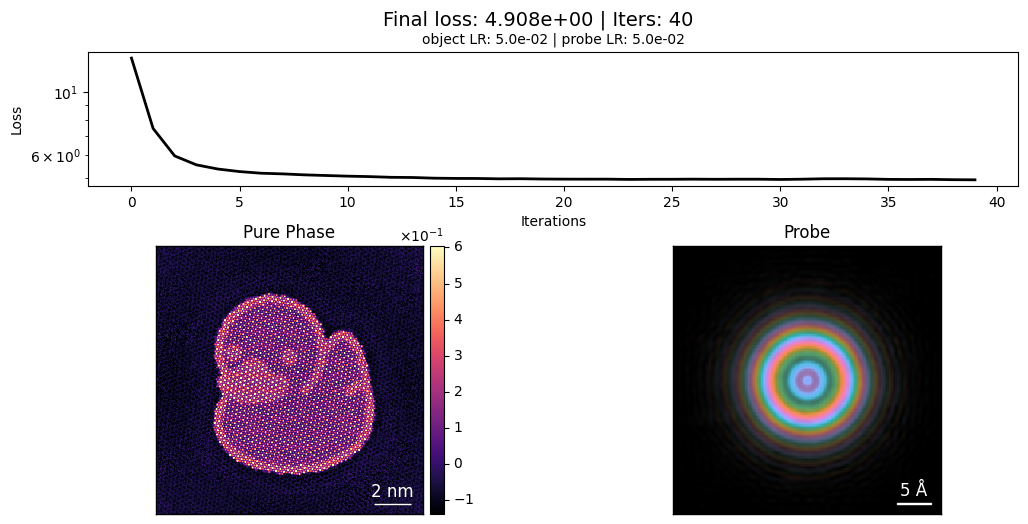

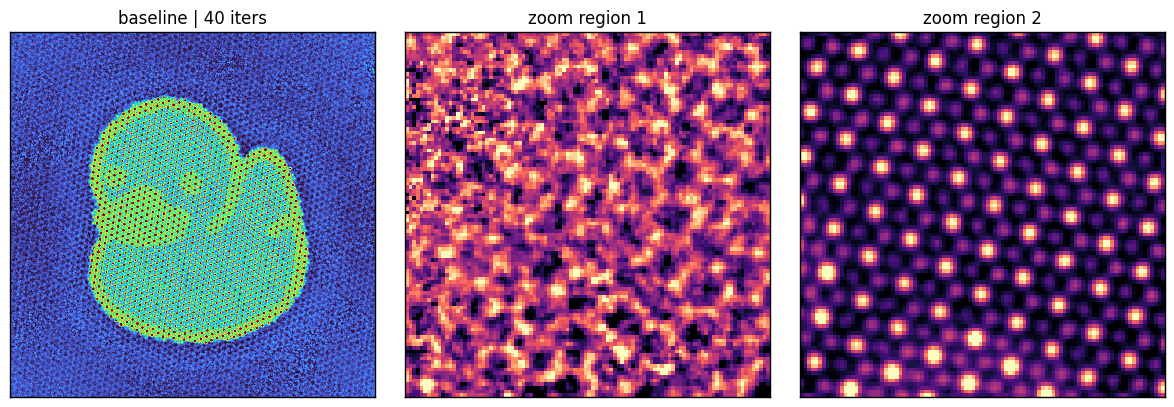

In [9]:
ptycho.logger = make_logger("01_baseline")
ptycho.reconstruct(
    num_iters=NUM_ITERS,
    reset=True,
    optimizer_params=OPT,
    scheduler_params=SCHED,
    batch_size=BATCH,
    device=DEVICE,
).visualize()
show_zoom(ptycho, "baseline")

## 2. Object constraints

All `ObjectModel` constraints live on `PtychoObjConstraintParams.Raster`.
The fields fall into three groups:

- **Hard projections (per-update):** `positivity`, `positivity_mode`,
  `fix_potential_baseline`, `fix_potential_baseline_factor`, `identical_slices`,
  `apply_fov_mask`
- **Real-space filters (per-update):** `gaussian_sigma`, `butterworth_order`,
  `q_lowpass`, `q_highpass`
- **Soft penalties (in the loss):** `tv_weight_z`, `tv_weight_xy`,
  `surface_zero_weight`

For `obj_type="potential"`, `positivity_mode` picks how non-negativity is enforced:

- `"clamp"` (default) — straight-through `clamp(≥0)` in the forward. The displayed/used
  object is non-negative, but the underlying parameter is left free (no actual background
  shrinkage).
- `"shrink"` — after each optimizer step, subtract
  `fix_potential_baseline_factor × (per-slice background)` from the object parameter, then
  clamp `≥0`. This pushes each slice's background toward zero in the reconstruction itself.
  Being per-slice keeps it on loss-neutral, which is important for
  multislice stability. Here
  `fix_potential_baseline_factor` is the shrink rate (small values typically work best, ~0.1).

### 2a. Gaussian blur as a smoothing prior
Apply a small Gaussian after every update — biases the reconstruction toward
smooth solutions.


  0%|          | 0/40 [00:00<?, ?it/s]

Iter 40/40, Loss: 4.581e+00: 100%|██████████| 40/40 [00:02<00:00, 14.99it/s]


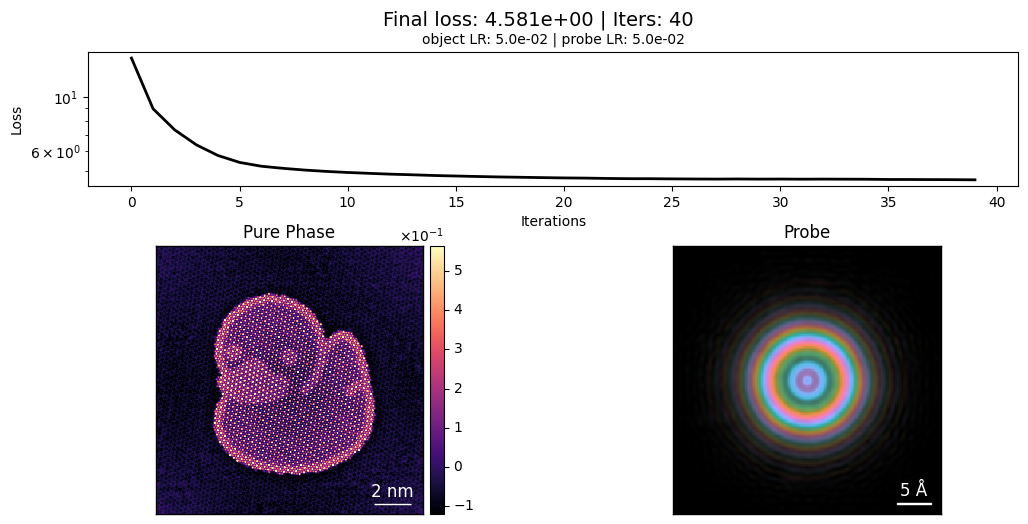

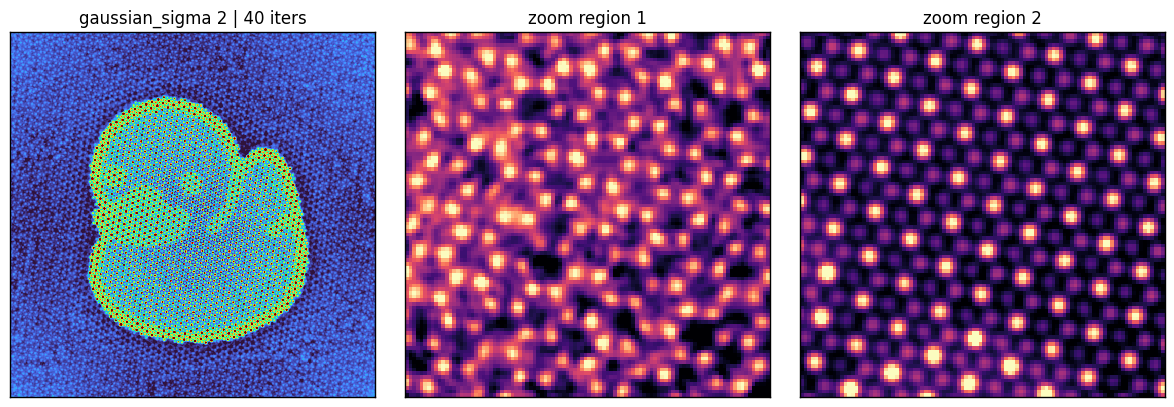

In [10]:
ptycho.logger = make_logger("02a_gaussian_sigma")
constraint = PtychoObjConstraintParams.Raster(gaussian_sigma=2)
ptycho.reconstruct(
    num_iters=NUM_ITERS,
    reset=True,
    optimizer_params=OPT,
    scheduler_params=SCHED,
    constraints={"object": constraint},
    batch_size=BATCH,
    device=DEVICE,
).visualize()
show_zoom(ptycho, f"gaussian_sigma {constraint.gaussian_sigma}")

### 2b. Butterworth low-pass
Filter out high-frequency content by setting `q_lowpass` (in A^-1).


  0%|          | 0/40 [00:00<?, ?it/s]

Iter 40/40, Loss: 6.666e+00: 100%|██████████| 40/40 [00:02<00:00, 15.22it/s]


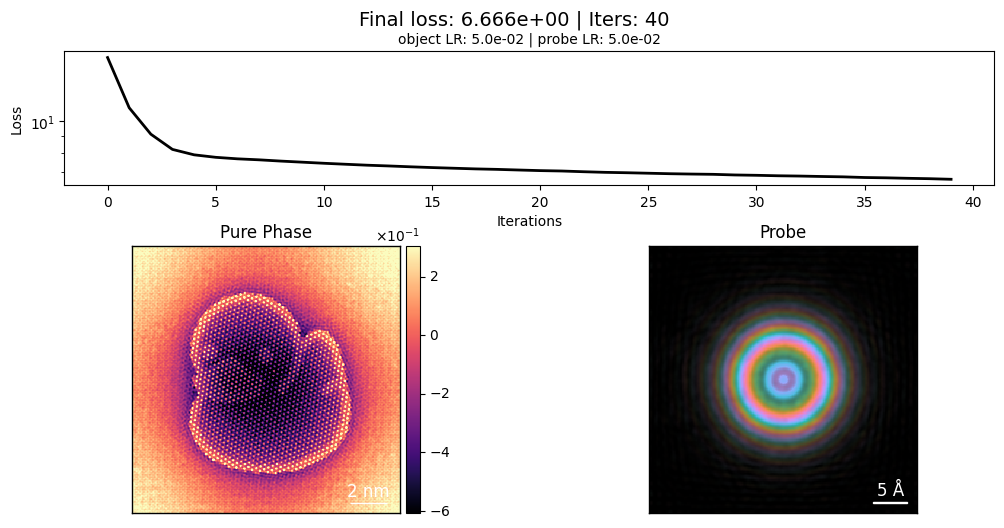

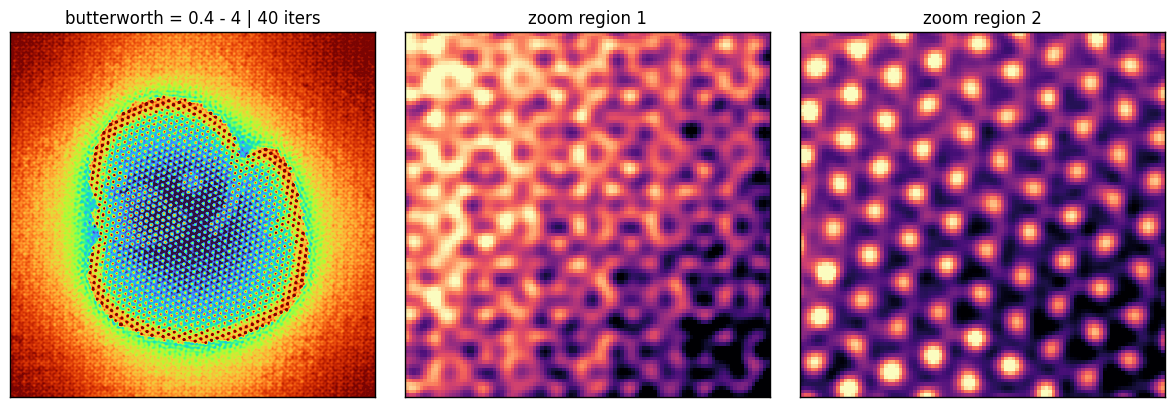

In [11]:
ptycho.logger = make_logger("02b_butterworth")
constraint = PtychoObjConstraintParams.Raster(
    q_lowpass=0.4,
    butterworth_order=4,
)
ptycho.reconstruct(
    num_iters=NUM_ITERS,
    reset=True,
    optimizer_params=OPT,
    scheduler_params=SCHED,
    constraints={"object": constraint},
    batch_size=BATCH,
    device=DEVICE,
).visualize()
show_zoom(ptycho, f"butterworth = {constraint.q_lowpass} - {constraint.butterworth_order}")

### 2c. Total variation (xy)
Adds an xy total-variation penalty to the loss — encourages piecewise-smooth
regions while preserving edges.


  0%|          | 0/40 [00:00<?, ?it/s]

Iter 40/40, Loss: 1.369e+01: 100%|██████████| 40/40 [00:02<00:00, 14.97it/s]


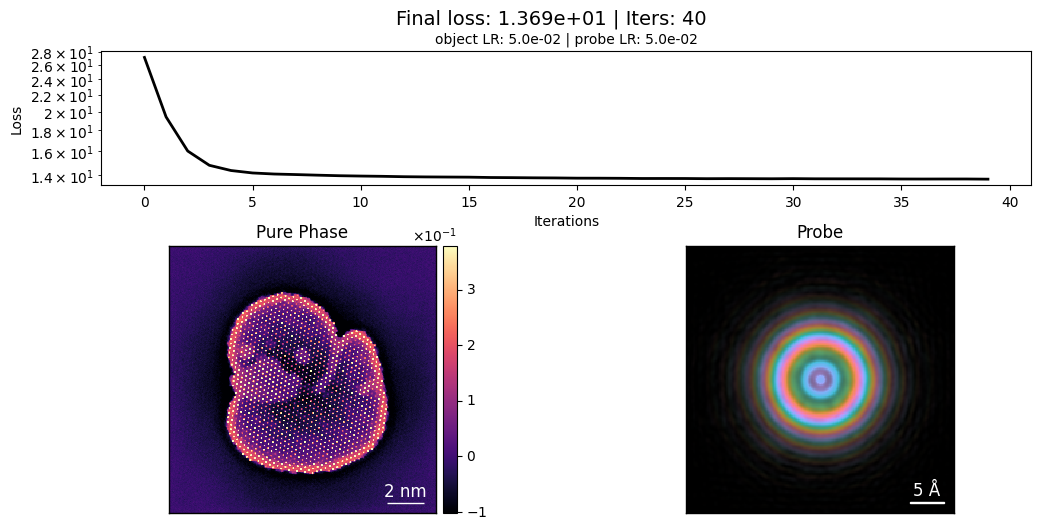

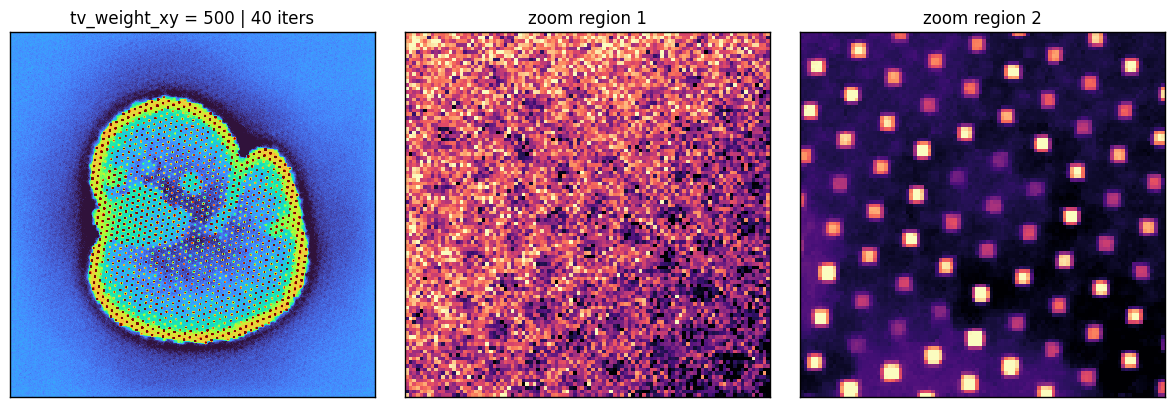

In [12]:
ptycho.logger = make_logger("02c_tv_xy")
constraint = PtychoObjConstraintParams.Raster(tv_weight_xy=500)
ptycho.reconstruct(
    num_iters=NUM_ITERS,
    reset=True,
    optimizer_params=OPT,
    scheduler_params=SCHED,
    constraints={"object": constraint},
    batch_size=BATCH,
    device=DEVICE,
).visualize()
show_zoom(ptycho, f"tv_weight_xy = {constraint.tv_weight_xy}")

### 2d. Multislice-only object constraints

Three fields on `PtychoObjConstraintParams.Raster` are only active when
`num_slices > 1`, so they don't change anything on this single-slice ducky
reconstruction:

- `identical_slices` — replaces all slices with their mean after every update;
  useful when you know the object is genuinely 2D and want to suppress
  out-of-plane variation.
- `tv_weight_z` — total-variation penalty along the slice axis; encourages
  smooth depth profiles.
- `surface_zero_weight` — penalizes amplitude/phase on the first and last
  slices; useful when the sample is known to be embedded in vacuum.

See `ptycho_iter_05_multislice.ipynb` for a full demonstration on a thick
sample where these constraints matter.


## 3. Probe constraints

`PtychoProbeConstraintParams.Raster` exposes three fields today:

- `orthogonalize_probe` (hard) — Gram-Schmidt on the mixed-state probe stack;
  on by default.
- `center_probe` (hard) — shift probe center-of-mass to image center each update.
- `tv_weight` (soft) — TV penalty on the probe magnitude.


### 3a. Center the probe

`PtychoProbeConstraintParams.Raster(center_probe=True)` shifts the probe's
intensity center-of-mass back to the array center after every update via a
Fourier shift. This is useful when probe drift competes with scan-position
refinement — the probe and scan positions can otherwise trade off against
each other and the reconstruction wanders.

On the ducky dataset (no descan, scan positions fixed) it has no visible
effect, so we skip the run. Enable it when you see the probe walking off
center in TensorBoard's probe snapshots.


### 3b. Soft TV penalty on the probe


  0%|          | 0/40 [00:00<?, ?it/s]

Iter 40/40, Loss: 1.725e+01: 100%|██████████| 40/40 [00:02<00:00, 14.24it/s]


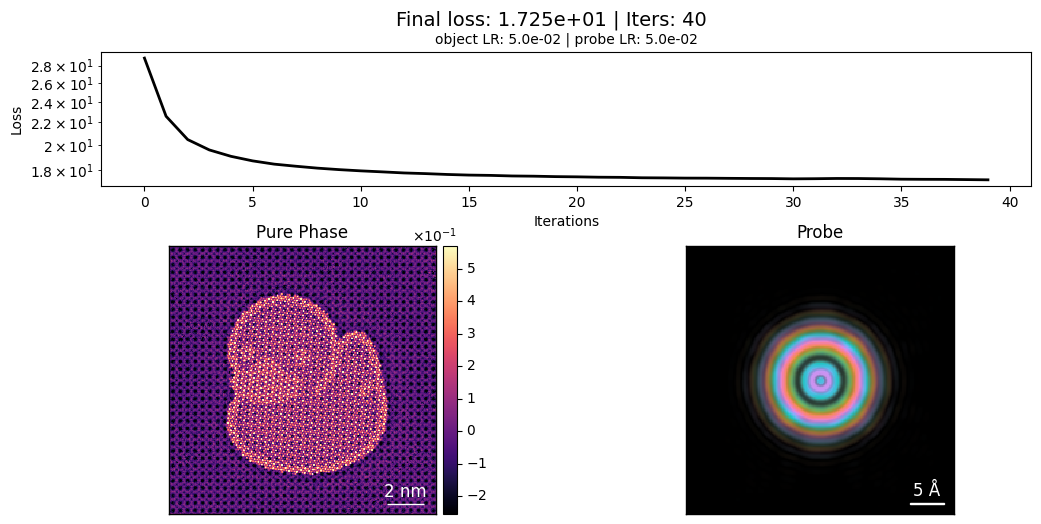

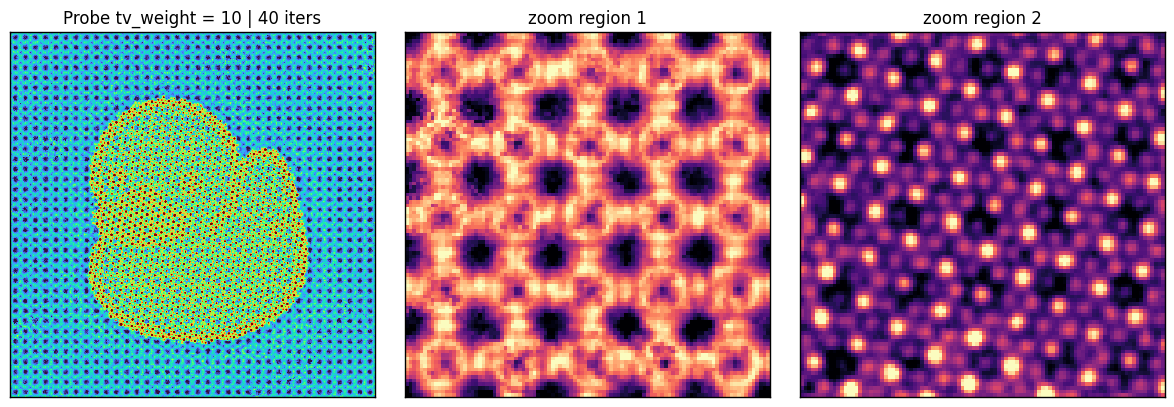

In [13]:
ptycho.logger = make_logger("03b_probe_tv")
constraint = PtychoProbeConstraintParams.Raster(tv_weight=10)
ptycho.reconstruct(
    num_iters=NUM_ITERS,
    reset=True,
    optimizer_params=OPT,
    scheduler_params=SCHED,
    constraints={"probe": constraint},
    batch_size=BATCH,
    device=DEVICE,
).visualize()
show_zoom(ptycho, f"Probe tv_weight = {constraint.tv_weight}")

## 4. Dataset constraints

`PtychoDatasetConstraintParams.Raster` covers scan-position and descan behavior:

- `clip_scan_positions` (hard, default `True`) — keeps scan positions inside
  the object FOV after every update.
- `center_scan_positions` (hard) — re-centers the mean scan position to the
  object center each iteration.
- `descan_shifts_zero` (hard) — zeroes descan shifts (useful when descan
  is not being refined). Distinct from `learn_descan=False`, which holds descan
  at its fitted value rather than forcing it to zero.
- `descan_tv_weight` (soft) — TV penalty on the descan-shift sequence; only
  active when the dataset has a descan optimizer.

### 4a. Center scan positions

`PtychoDatasetConstraintParams.Raster(center_scan_positions=True)` shifts all
scan positions uniformly so their mean sits at the object center after every
update. This prevents the whole reconstruction from translating during long
runs when scan positions are being refined.

Like the probe-centering constraint above, this has no visible effect on
ducky because scan positions are fixed; reach for it when you turn on
`lr_scan_positions` and want to keep the object anchored.


## 5. Combining constraints across all three models

Each kwarg is independent; you can pass any combination.


  0%|          | 0/40 [00:00<?, ?it/s]

Iter 40/40, Loss: 5.113e+00: 100%|██████████| 40/40 [00:02<00:00, 13.39it/s]


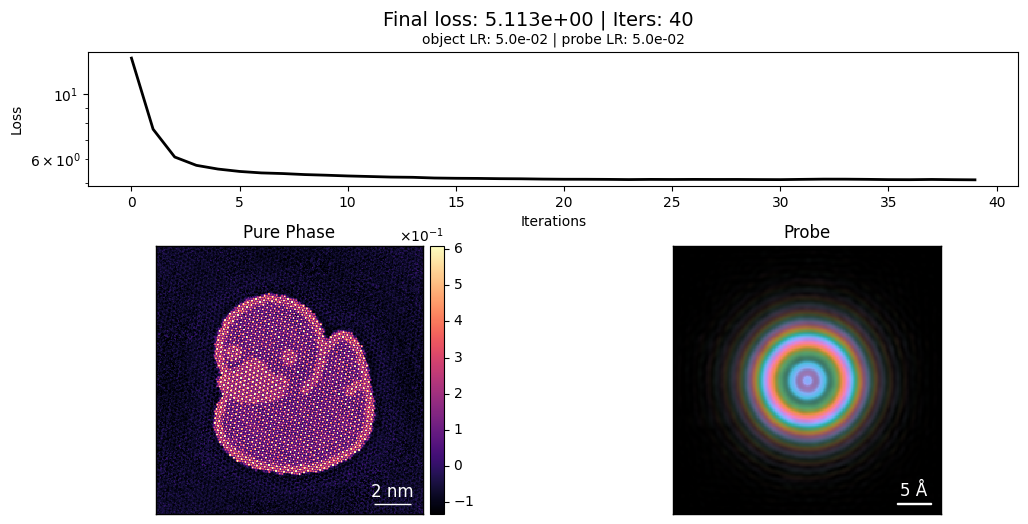

In [14]:
ptycho.logger = make_logger("05_combined")
ptycho.reconstruct(
    num_iters=NUM_ITERS,
    reset=True,
    optimizer_params=OPT,
    scheduler_params=SCHED,
    constraints={
        "object": PtychoObjConstraintParams.Raster(
            gaussian_sigma=0.5,
            tv_weight_xy=10,
        ),
        "probe": PtychoProbeConstraintParams.Raster(center_probe=True),
        "dataset": PtychoDatasetConstraintParams.Raster(center_scan_positions=True),
    },
    batch_size=BATCH,
    device=DEVICE,
).visualize()

## Recap

- Constraints are typed dataclasses, discoverable via tab-complete and `__str__`.
- Pass them through a single `constraints={...}` dict keyed by `"object"`,
  `"probe"`, `"dataset"`. Any subset is fine.
- Each leaf may be a dataclass instance (wholesale replace) or a plain dict
  (partial update of defaults).
- TensorBoard makes constraint comparisons easy — run with distinct `run_suffix`
  values per experiment.
